# Hypotension obs24_target8_gap0 Cluster Visualization

Load saved autoencoder embeddings, cluster assignments, importance maps, and prepared tensors for the `vit_baseline/obs24_target8_gap0/hypotension` run, then render cluster heatmaps with normal-range coloring.

## Imports and Paths

In [1]:
from __future__ import annotations

import json
import logging
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "interpretable_ts_vit").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from interpretable_ts_vit.binning import TimeSeriesBinner
from interpretable_ts_vit.io import load_split
from interpretable_ts_vit.visualization import (
    aggregate_cluster_value_matrices,
    cluster_assignment_counts,
    patient_value_matrix,
    plot_importance_heatmap,
    plot_value_heatmap,
    value_ranges_by_variable,
)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(name)s: %(message)s",
    force=True,
)
logger = logging.getLogger("hypotension_cluster_visualization")
logger.info("Project root: %s", PROJECT_ROOT)

2026-07-13 20:11:18,840 INFO hypotension_cluster_visualization: Project root: /home/michalwe/Interpretable-ViT-for-Timeseries


In [2]:
EXPERIMENT_NAME = "vit_baseline"
TARGET = "hypotension"
WINDOW = "obs24_target8_gap0"
SPLIT = "test"

RUN_DIR = PROJECT_ROOT / "runs" / "mimic_targets" / EXPERIMENT_NAME / WINDOW / TARGET
PROCESSED_DIR = PROJECT_ROOT / "data" / "mimic_targets" / "processed" / WINDOW / TARGET
CLUSTERS_DIR = RUN_DIR / "clusters" / SPLIT
EXPLANATIONS_DIR = RUN_DIR / "explanations" / SPLIT
OUTPUT_DIR = RUN_DIR / "cluster_heatmaps" / SPLIT
SELECTED_OUTPUT_DIR = RUN_DIR / "selected_cluster_heatmaps" / SPLIT
SELECTED_PATIENT_OUTPUT_DIR = RUN_DIR / "selected_patient_heatmaps" / SPLIT
NORMAL_RANGES_PATH = PROJECT_ROOT / "src" / "interpretable_ts_vit" / "normal_ranges.json"

PLOT_MODE = "value_with_importance_opacity"
IMPORTANCE_THRESHOLD = None
TOP_IMPORTANCE_PERCENTAGE = 0.1
SELECT_BEST_N_CLUSTERS = True
N_CLUSTER_CANDIDATES = range(2, 13)
SHOW_VALUES = True
USE_NORMAL_RANGES = True

RUN_DIR

PosixPath('/home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension')

## Load Saved Artifacts

In [3]:
def require_artifacts(paths):
    missing = [f"{name}: {path}" for name, path in paths.items() if not Path(path).exists()]
    if missing:
        raise FileNotFoundError("Missing required artifact(s):\n" + "\n".join(missing))


def safe_path_component(value):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("_") or "class"


def embedding_feature_columns(embedding_frame):
    return [column for column in embedding_frame.columns if column != "patient_id"]


def nearest_centroid_flags(labels, distances):
    flags = np.zeros(len(labels), dtype=bool)
    for label in sorted(set(labels)):
        indices = np.where(labels == label)[0]
        if len(indices) == 0:
            continue
        flags[indices[np.argmin(distances[indices])]] = True
    return flags.tolist()


def cluster_frame_for_class(group, feature_columns, n_clusters, random_state=13):
    x = group[feature_columns].to_numpy(dtype=np.float64)
    scaled = StandardScaler().fit_transform(x)
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(scaled).astype(int)
    distances = np.linalg.norm(scaled - kmeans.cluster_centers_[labels], axis=1)
    return pd.DataFrame({
        "patient_id": group["patient_id"].astype(str).to_numpy(),
        "predicted_label": str(group["predicted_label"].iloc[0]),
        "cluster": labels,
        "distance_to_centroid": distances,
        "is_centroid": nearest_centroid_flags(labels, distances),
    })


def silhouette_scores_for_class(group, feature_columns, candidate_clusters, random_state=13):
    x = group[feature_columns].to_numpy(dtype=np.float64)
    scaled = StandardScaler().fit_transform(x)
    rows = []
    for candidate in candidate_clusters:
        n_clusters = int(candidate)
        if n_clusters < 2 or n_clusters >= len(group):
            continue
        labels = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10).fit_predict(scaled)
        rows.append({
            "predicted_label": str(group["predicted_label"].iloc[0]),
            "n_clusters": n_clusters,
            "silhouette_score": float(silhouette_score(scaled, labels)),
            "n_patients": len(group),
        })
    return rows


def write_cluster_importance_aggregates(output_dir, assignment_frame, explanations_dir):
    group_columns = ["predicted_label", "cluster"] if "predicted_label" in assignment_frame.columns else ["cluster"]
    for group_key, group in assignment_frame.groupby(group_columns, sort=True):
        matrices = []
        for patient_id in group["patient_id"].astype(str):
            path = explanations_dir / f"{patient_id}.npy"
            if path.exists():
                matrices.append(np.load(path))
        if not matrices:
            continue
        aggregate = np.mean(matrices, axis=0)
        predicted_label, cluster = group_key
        output_path = output_dir / safe_path_component(predicted_label) / f"cluster_{int(cluster)}.npy"
        output_path.parent.mkdir(parents=True, exist_ok=True)
        np.save(output_path, aggregate)


def select_best_silhouette_clusters(embedding_frame, previous_assignments, candidate_clusters, clusters_dir, explanations_dir):
    feature_columns = embedding_feature_columns(embedding_frame)
    label_frame = previous_assignments[["patient_id", "predicted_label"]].drop_duplicates().copy()
    work = embedding_frame.merge(label_frame, on="patient_id", how="inner")
    if work.empty:
        raise ValueError("No embeddings matched predicted labels from the current cluster assignments.")

    score_rows = []
    assignment_frames = []
    selected_by_class = {}
    for predicted_label, group in work.groupby("predicted_label", sort=True):
        group = group.reset_index(drop=True)
        class_scores = silhouette_scores_for_class(group, feature_columns, candidate_clusters)
        score_rows.extend(class_scores)
        if class_scores:
            best = max(class_scores, key=lambda row: row["silhouette_score"])
            selected_n = int(best["n_clusters"])
            selected_score = float(best["silhouette_score"])
        else:
            selected_n = 1
            selected_score = np.nan
        selected_by_class[str(predicted_label)] = {"n_clusters": selected_n, "silhouette_score": selected_score, "n_patients": len(group)}
        assignment_frames.append(cluster_frame_for_class(group, feature_columns, selected_n))

    selected_assignments = pd.concat(assignment_frames, ignore_index=True)
    selected_centroids = selected_assignments[selected_assignments["is_centroid"]].reset_index(drop=True)
    selected_assignments.to_csv(clusters_dir / "cluster_assignments.csv", index=False)
    selected_centroids.to_csv(clusters_dir / "cluster_centroids.csv", index=False)
    write_cluster_importance_aggregates(clusters_dir, selected_assignments, explanations_dir)

    metadata = json.loads((clusters_dir / "cluster_metadata.json").read_text(encoding="utf-8"))
    metadata["n_cluster_selection"] = {
        "metric": "silhouette_score",
        "candidate_clusters": [int(value) for value in candidate_clusters],
        "selected_by_class": selected_by_class,
    }
    metadata["n_clusters_used"] = {label: values["n_clusters"] for label, values in selected_by_class.items()}
    metadata["n_clusters_requested"] = {label: values["n_clusters"] for label, values in selected_by_class.items()}
    (clusters_dir / "cluster_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    return pd.DataFrame(score_rows), selected_assignments, selected_centroids, metadata


required = {
    "prepared binner": PROCESSED_DIR / "binner.json",
    f"prepared {SPLIT} split": PROCESSED_DIR / f"{SPLIT}.npz",
    "run binner": RUN_DIR / "binner.json",
    f"run {SPLIT} split": RUN_DIR / f"{SPLIT}.npz",
    "autoencoder embeddings": CLUSTERS_DIR / "autoencoder_embeddings.csv",
    "cluster assignments": CLUSTERS_DIR / "cluster_assignments.csv",
    "cluster centroids": CLUSTERS_DIR / "cluster_centroids.csv",
    "cluster metadata": CLUSTERS_DIR / "cluster_metadata.json",
    f"{SPLIT} explanations": EXPLANATIONS_DIR,
    "normal ranges": NORMAL_RANGES_PATH,
}
require_artifacts(required)

binner = TimeSeriesBinner.load(PROCESSED_DIR / "binner.json")
dataset = load_split(PROCESSED_DIR / f"{SPLIT}.npz")
embeddings = pd.read_csv(CLUSTERS_DIR / "autoencoder_embeddings.csv", dtype={"patient_id": str})
assignments = pd.read_csv(CLUSTERS_DIR / "cluster_assignments.csv", dtype={"patient_id": str})
if SELECT_BEST_N_CLUSTERS:
    silhouette_results, assignments, centroids, cluster_metadata = select_best_silhouette_clusters(
        embeddings,
        assignments,
        N_CLUSTER_CANDIDATES,
        CLUSTERS_DIR,
        EXPLANATIONS_DIR,
    )
else:
    silhouette_results = pd.DataFrame()
    centroids = pd.read_csv(CLUSTERS_DIR / "cluster_centroids.csv", dtype={"patient_id": str})
    cluster_metadata = json.loads((CLUSTERS_DIR / "cluster_metadata.json").read_text(encoding="utf-8"))

patient_ids_by_cluster = {
    (str(predicted_label), int(cluster)): group["patient_id"].astype(str).tolist()
    for (predicted_label, cluster), group in assignments.groupby(["predicted_label", "cluster"], sort=True)
}
patient_ids_by_cluster_table = pd.DataFrame(
    [
        {
            "predicted_label": predicted_label,
            "cluster": cluster,
            "n_patients": len(patient_ids),
            "patient_ids": patient_ids,
            "patient_ids_preview": ", ".join(patient_ids[:10]) + (" ..." if len(patient_ids) > 10 else ""),
        }
        for (predicted_label, cluster), patient_ids in patient_ids_by_cluster.items()
    ]
)

display(pd.DataFrame([
    {"artifact": "embeddings", "path": str(CLUSTERS_DIR / "autoencoder_embeddings.csv"), "rows": len(embeddings)},
    {"artifact": "assignments", "path": str(CLUSTERS_DIR / "cluster_assignments.csv"), "rows": len(assignments)},
    {"artifact": "centroids", "path": str(CLUSTERS_DIR / "cluster_centroids.csv"), "rows": len(centroids)},
    {"artifact": "prepared split", "path": str(PROCESSED_DIR / f"{SPLIT}.npz"), "rows": len(dataset)},
]))
if not silhouette_results.empty:
    display(silhouette_results.sort_values(["predicted_label", "silhouette_score"], ascending=[True, False]))
display(patient_ids_by_cluster_table[["predicted_label", "cluster", "n_patients", "patient_ids_preview"]])
display(embeddings.head())
cluster_metadata

2026-07-13 20:11:18,859 INFO interpretable_ts_vit.binning: Loading binner metadata from /home/michalwe/Interpretable-ViT-for-Timeseries/data/mimic_targets/processed/obs24_target8_gap0/hypotension/binner.json
2026-07-13 20:11:18,860 INFO interpretable_ts_vit.binning: Loaded binner metadata from /home/michalwe/Interpretable-ViT-for-Timeseries/data/mimic_targets/processed/obs24_target8_gap0/hypotension/binner.json: variables=30, time_bins=48
2026-07-13 20:11:18,861 INFO interpretable_ts_vit.io: Loading split from /home/michalwe/Interpretable-ViT-for-Timeseries/data/mimic_targets/processed/obs24_target8_gap0/hypotension/test.npz
2026-07-13 20:11:19,212 INFO interpretable_ts_vit.data: Created BinnedTimeSeriesDataset: x_shape=(14966, 2, 30, 48), labels=True, patient_ids=True
2026-07-13 20:11:19,212 INFO interpretable_ts_vit.io: Loaded split from /home/michalwe/Interpretable-ViT-for-Timeseries/data/mimic_targets/processed/obs24_target8_gap0/hypotension/test.npz: patients=14966, x_shape=(14966

,artifact,path,rows
0,embeddings,/home/michalwe/Interpretable-ViT-for-Timeserie...,14966
1,assignments,/home/michalwe/Interpretable-ViT-for-Timeserie...,14966
2,centroids,/home/michalwe/Interpretable-ViT-for-Timeserie...,16
3,prepared split,/home/michalwe/Interpretable-ViT-for-Timeserie...,14966


,predicted_label,cluster,n_patients,patient_ids_preview
0,False,0,365,"30003087, 30024979, 30033179, 30059803, 300724..."
1,False,1,695,"30009596, 30014139, 30052861, 30056157, 300580..."
2,False,2,481,"30017473, 30023537, 30058866, 30094342, 301091..."
3,False,3,880,"30064922, 30065706, 30069861, 30072026, 300767..."
4,False,4,344,"30065121, 30123239, 30134437, 30170150, 301751..."
5,False,5,379,"30004462, 30043033, 30093234, 30099067, 301554..."
6,False,6,635,"30015010, 30028237, 30037708, 30042316, 300550..."
7,False,7,406,"30002415, 30017572, 30025933, 30026588, 300573..."
8,True,0,1301,"30024067, 30029746, 30036116, 30039849, 300457..."
9,True,1,1343,"30003306, 30005366, 30006731, 30014984, 300454..."


,patient_id,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,embedding_10,embedding_11,embedding_12,embedding_13,embedding_14,embedding_15
0,30002415,1.001699,-0.211203,0.033485,-0.406974,0.899025,-0.307698,0.447898,0.171896,2.391237,1.799503,-1.799359,-1.833847,-0.056946,-1.377698,0.408399,0.138537
1,30003087,1.111597,1.022253,-0.456775,0.363655,0.431915,-2.825986,-0.231618,-1.047251,0.813740,-1.074443,0.082583,0.359372,2.256319,1.315713,-1.540258,-1.561230
2,30003306,-1.586022,1.005692,-0.168026,0.339614,2.108833,-1.841140,2.527224,0.954676,1.601613,-0.444808,1.409994,0.685996,0.997365,-1.263898,1.028630,1.329969
3,30004462,-0.333865,3.347915,-0.405073,1.465904,0.574989,-1.739621,-0.080421,0.928665,3.523982,1.600218,0.930972,-3.387756,-1.866830,-0.471205,-2.294868,-1.258345
4,30004811,-1.736360,-0.225794,-2.133780,1.137271,3.455788,-2.752162,-0.794722,-0.707638,-0.274987,-1.680902,0.572300,0.286201,3.188778,0.422710,0.413718,0.104176


{'feature_mode': 'autoencoder',
 'class_specific': True,
 'clustering_method': 'kmeans',
 'centroid_definition': 'nearest patient to cluster centroid in scaled autoencoder latent space',
 'n_clusters_requested': 8,
 'n_clusters_used': {'False': 8, 'True': 8},
 'hdbscan_min_cluster_size': 5,
 'hdbscan_min_samples': None,
 'autoencoder_architecture': 'vit',
 'train': {'n_patients': 44897, 'nan_cells': 58328849},
 'validation': {'n_patients': 14966, 'nan_cells': 19444964},
 'input_shape': [2, 30, 48],
 'patch_size': [1, 4],
 'latent_dim': 16,
 'autoencoder_epochs': 50,
 'autoencoder_learning_rate': 0.001,
 'autoencoder_batch_size': 32,
 'autoencoder_early_stopping_patience': 10,
 'cluster': {'n_patients': 14966, 'nan_cells': 19448450},
 'autoencoder_train_loss': 0.4043208696750189,
 'autoencoder_val_loss': 4874.4764405517635,
 'autoencoder_cluster_loss': 4358.052422521485,
 'autoencoder_best_epoch': 30,
 'autoencoder_final_loss': 4358.052422521485}

## Plot Helpers

In [4]:
def safe_path_component(value):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("_") or "class"


def normalize_plot_mode(plot_mode):
    aliases = {
        "value": "values",
        "values": "values",
        "value_only": "values",
        "only_values": "values",
        "importance": "importance",
        "importance_only": "importance",
        "only_importance": "importance",
        "combined": "combined",
        "top_importance": "top_importance",
        "top_importances": "top_importance",
        "top_importance_values": "top_importance",
        "top": "top_importance",
        "value_with_importance_opacity": "combined",
        "value_with_importance_border": "combined",
    }
    try:
        return aliases[str(plot_mode)]
    except KeyError as exc:
        raise ValueError("plot_mode must be 'values', 'importance', 'combined', or 'top_importance'.") from exc


def importance_style_from_plot_mode(plot_mode):
    if str(plot_mode) == "value_with_importance_border":
        return "border"
    return "contour" if normalize_plot_mode(plot_mode) == "combined" else None


def normalize_importance_encoding(importance_encoding):
    aliases = {
        "contour": "contour",
        "contours": "contour",
        "marker": "markers",
        "markers": "markers",
        "side_strip": "side_strip",
        "strip": "side_strip",
        "side": "side_strip",
        "spotlight": "spotlight",
        "dark_overlay": "spotlight",
        "pattern": "pattern",
        "patterns": "pattern",
        "hatch": "pattern",
        "hatching": "pattern",
        "yellow_glow": "yellow_glow",
        "glow": "yellow_glow",
        "yellow": "yellow_glow",
    }
    try:
        return aliases[str(importance_encoding)]
    except KeyError as exc:
        raise ValueError("importance_encoding must be 'contour', 'markers', 'side_strip', 'spotlight', 'pattern', or 'yellow_glow'.") from exc


def top_importance_value_matrix(value_matrix, importance_matrix, percentage):
    percentage = float(percentage)
    if not 0.0 < percentage <= 1.0:
        raise ValueError("top_importance_percentage must be in (0, 1]. For example, 0.1 plots the top 10% importance scores.")
    if importance_matrix.shape != value_matrix.shape:
        raise ValueError(f"Importance matrix shape {importance_matrix.shape} does not match value matrix shape {value_matrix.shape}.")
    finite_mask = np.isfinite(value_matrix) & np.isfinite(importance_matrix)
    finite_importance = importance_matrix[finite_mask]
    if finite_importance.size == 0:
        raise ValueError("No finite value/importance cells are available for top-importance plotting.")
    cutoff = np.quantile(finite_importance, 1.0 - percentage)
    top_mask = finite_mask & (importance_matrix >= cutoff)
    top_matrix = np.full_like(value_matrix, np.nan, dtype=np.float64)
    top_matrix[top_mask] = value_matrix[top_mask]
    return top_matrix


def cluster_key_from_group_key(group_key, group_columns):
    if group_columns == ["cluster"]:
        return int(group_key)
    predicted_label, cluster = group_key
    return str(predicted_label), int(cluster)


def heatmap_path(output_dir, cluster_key):
    if isinstance(cluster_key, tuple):
        predicted_label, cluster = cluster_key
        return output_dir / safe_path_component(predicted_label) / f"cluster_{cluster}.png"
    return output_dir / f"cluster_{cluster_key}.png"


def importance_matrix_path(cluster_key):
    if isinstance(cluster_key, tuple):
        predicted_label, cluster = cluster_key
        return CLUSTERS_DIR / safe_path_component(predicted_label) / f"cluster_{cluster}.npy"
    return CLUSTERS_DIR / f"cluster_{cluster_key}.npy"


def cluster_title(cluster_key, count):
    suffix = f" (n={count})" if count is not None else ""
    if isinstance(cluster_key, tuple):
        predicted_label, cluster = cluster_key
        return f"Predicted class {predicted_label}: cluster_{cluster}{suffix}"
    return f"cluster_{cluster_key}{suffix}"


def normal_ranges_arg():
    return NORMAL_RANGES_PATH if USE_NORMAL_RANGES else None


def load_importance_matrix(cluster_key):
    path = importance_matrix_path(cluster_key)
    if path.exists():
        return np.load(path)
    logger.warning("Missing importance matrix: %s", path)
    return None


def render_cluster_heatmap(cluster_key, matrix, output_dir, count=None, vmin=None, vmax=None, display_image=True, plot_mode=None, top_importance_percentage=None):
    raw_plot_mode = PLOT_MODE if plot_mode is None else plot_mode
    plot_mode = normalize_plot_mode(raw_plot_mode)
    top_importance_percentage = TOP_IMPORTANCE_PERCENTAGE if top_importance_percentage is None else float(top_importance_percentage)
    importance_style = importance_style_from_plot_mode(raw_plot_mode)
    importance_matrix = load_importance_matrix(cluster_key) if importance_style is not None or plot_mode == "top_importance" else None
    if plot_mode == "top_importance" and importance_matrix is None:
        raise ValueError(f"No cluster importance matrix found for {cluster_key!r}.")
    if vmin is None or vmax is None:
        vmin, vmax = value_ranges_by_variable([matrix])
    matrix_for_plot = top_importance_value_matrix(matrix, importance_matrix, top_importance_percentage) if plot_mode == "top_importance" else matrix
    output_path = heatmap_path(output_dir, cluster_key)
    if plot_mode == "top_importance":
        output_path = output_path.with_name(f"{output_path.stem}_top_importance_{int(round(top_importance_percentage * 100))}pct{output_path.suffix}")
    plot_value_heatmap(
        matrix_for_plot,
        binner.variable_vocab_,
        binner.time_bins_,
        output_path,
        title=f"{cluster_title(cluster_key, count)} top {top_importance_percentage:.0%} importance values" if plot_mode == "top_importance" else cluster_title(cluster_key, count),
        vmin=vmin,
        vmax=vmax,
        importance_matrix=importance_matrix,
        importance_style=importance_style or "opacity",
        importance_threshold=IMPORTANCE_THRESHOLD,
        show_values=SHOW_VALUES,
        normal_ranges=normal_ranges_arg(),
    )
    if display_image:
        print(output_path)
        display(Image(filename=str(output_path)))
    return output_path


def cluster_value_matrices(assignments_frame=None):
    frame = assignments if assignments_frame is None else assignments_frame
    return aggregate_cluster_value_matrices(dataset, frame, binner)


def plot_all_clusters(display_images=True, plot_mode=None, top_importance_percentage=None):
    matrices_by_cluster = cluster_value_matrices()
    counts_by_cluster = cluster_assignment_counts(assignments)
    if not matrices_by_cluster:
        raise ValueError("No cluster value matrices were created.")
    vmin, vmax = value_ranges_by_variable(list(matrices_by_cluster.values()))
    paths = []
    for cluster_key, matrix in matrices_by_cluster.items():
        paths.append(render_cluster_heatmap(
            cluster_key,
            matrix,
            OUTPUT_DIR,
            count=counts_by_cluster.get(cluster_key),
            vmin=vmin,
            vmax=vmax,
            display_image=display_images,
            plot_mode=plot_mode,
            top_importance_percentage=top_importance_percentage,
        ))
    return paths


def plot_selected_cluster(class_label, cluster_number, plot_mode=None, top_importance_percentage=None):
    class_label = str(class_label)
    cluster_number = int(cluster_number)
    selected = assignments[
        (assignments["predicted_label"].astype(str) == class_label)
        & (assignments["cluster"].astype(int) == cluster_number)
    ].copy()
    if selected.empty:
        available = assignments.groupby(["predicted_label", "cluster"]).size().rename("patients").reset_index()
        display(available)
        raise ValueError(f"No patients found for predicted_label={class_label!r}, cluster={cluster_number}.")
    matrices = cluster_value_matrices(selected)
    cluster_key = (class_label, cluster_number)
    matrix = matrices.get(cluster_key)
    if matrix is None:
        matrix = next(iter(matrices.values()))
    return render_cluster_heatmap(cluster_key, matrix, SELECTED_OUTPUT_DIR, count=len(selected), plot_mode=plot_mode, top_importance_percentage=top_importance_percentage)


def patients_in_cluster(class_label, cluster_number):
    class_label = str(class_label)
    cluster_number = int(cluster_number)
    selected = assignments[
        (assignments["predicted_label"].astype(str) == class_label)
        & (assignments["cluster"].astype(int) == cluster_number)
    ].copy()
    if selected.empty:
        available = assignments.groupby(["predicted_label", "cluster"]).size().rename("patients").reset_index()
        display(available)
        raise ValueError(f"No patients found for predicted_label={class_label!r}, cluster={cluster_number}.")
    return selected.sort_values(["is_centroid", "distance_to_centroid"], ascending=[False, True]).reset_index(drop=True)


def choose_patient_from_cluster(class_label, cluster_number, patient_id=None):
    selected = patients_in_cluster(class_label, cluster_number)
    if patient_id is None:
        centroid_rows = selected[selected["is_centroid"].astype(bool)]
        return str((centroid_rows if not centroid_rows.empty else selected).iloc[0]["patient_id"])
    patient_id = str(patient_id)
    if patient_id not in set(selected["patient_id"].astype(str)):
        display(selected.head(25))
        raise ValueError(f"Patient {patient_id!r} is not in predicted_label={class_label!r}, cluster={cluster_number}.")
    return patient_id


def plot_patient_from_cluster(class_label, cluster_number, patient_id=None, plot_mode=None, importance_encoding="contour", top_importance_percentage=0.1):
    class_label = str(class_label)
    cluster_number = int(cluster_number)
    plot_mode = normalize_plot_mode(PLOT_MODE if plot_mode is None else plot_mode)
    patient_id = choose_patient_from_cluster(class_label, cluster_number, patient_id)
    matrix = patient_value_matrix(dataset, binner, patient_id)
    explanation_path = EXPLANATIONS_DIR / f"{patient_id}.npy"
    importance_matrix = np.load(explanation_path) if explanation_path.exists() else None
    if importance_matrix is None:
        logger.warning("No patient explanation found: %s", explanation_path)
    if plot_mode == "combined":
        importance_encoding = normalize_importance_encoding(importance_encoding)
    if plot_mode == "top_importance":
        top_importance_percentage = float(top_importance_percentage)
    output_suffix = {
        "values": "values",
        "importance": "importance",
        "combined": f"combined_{importance_encoding}",
        "top_importance": f"top_importance_{int(round(float(top_importance_percentage) * 100))}pct",
    }[plot_mode]
    output_path = SELECTED_PATIENT_OUTPUT_DIR / safe_path_component(class_label) / f"cluster_{cluster_number}" / f"patient_{safe_path_component(patient_id)}_{output_suffix}.png"
    title = f"Predicted class {class_label}: cluster_{cluster_number}, patient {patient_id}"

    if plot_mode in {"importance", "top_importance"} and importance_matrix is None:
        raise ValueError(f"No patient explanation found for patient {patient_id!r}: {explanation_path}")

    if plot_mode == "importance":
        plot_importance_heatmap(
            importance_matrix,
            binner.variable_vocab_,
            binner.time_bins_,
            output_path,
            title=f"{title} importance",
            importance_threshold=IMPORTANCE_THRESHOLD,
        )
    else:
        vmin, vmax = value_ranges_by_variable([matrix])
        matrix_for_plot = top_importance_value_matrix(matrix, importance_matrix, top_importance_percentage) if plot_mode == "top_importance" else matrix
        importance_matrix_for_plot = importance_matrix if plot_mode == "combined" else None
        plot_value_heatmap(
            matrix_for_plot,
            binner.variable_vocab_,
            binner.time_bins_,
            output_path,
            title=f"{title} top {top_importance_percentage:.0%} importance values" if plot_mode == "top_importance" else (title if plot_mode == "values" else f"{title} values + importance"),
            vmin=vmin,
            vmax=vmax,
            importance_matrix=importance_matrix_for_plot,
            importance_style=importance_encoding if plot_mode == "combined" else "opacity",
            importance_threshold=IMPORTANCE_THRESHOLD,
            show_values=SHOW_VALUES,
            normal_ranges=normal_ranges_arg(),
        )
    print(output_path)
    display(Image(filename=str(output_path)))
    return output_path


def plot_cluster_and_patient(class_label, cluster_number, patient_id=None, plot_mode=None, top_importance_percentage=0.1):
    patient_id = choose_patient_from_cluster(class_label, cluster_number, patient_id)
    return {
        "cluster": plot_selected_cluster(class_label, cluster_number, plot_mode=plot_mode, top_importance_percentage=top_importance_percentage),
        "patient": plot_patient_from_cluster(class_label, cluster_number, patient_id, plot_mode=plot_mode, top_importance_percentage=top_importance_percentage),
    }

## Plot All Clusters

In [5]:
# all_cluster_heatmaps = plot_all_clusters(display_images=True)
# len(all_cluster_heatmaps)

## Plot One Cluster

In [6]:
# Choose any available predicted_label / cluster pair from the table above.
# patient_ids_by_cluster[("True", 0)][:20]
# patients_in_cluster("True", 0).head()
# plot_selected_cluster("True", 0)
# plot_selected_cluster("True", 0, plot_mode="top_importance", top_importance_percentage=0.1)
# plot_all_clusters(plot_mode="top_importance", top_importance_percentage=0.1)
# plot_patient_from_cluster("True", 0)  # defaults to the centroid patient and global PLOT_MODE
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="values")
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="importance")
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="top_importance", top_importance_percentage=0.1)
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="combined")  # default: importance_encoding="contour"
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="combined", importance_encoding="contour")
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="combined", importance_encoding="markers")
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="combined", importance_encoding="side_strip")
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="combined", importance_encoding="spotlight")
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="combined", importance_encoding="pattern")
# plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="combined", importance_encoding="yellow_glow")
# plot_cluster_and_patient("False", 3)
# plot_cluster_and_patient("True", 0, patient_id="30024067", plot_mode="top_importance", top_importance_percentage=0.1)

In [7]:
patient_ids_by_cluster[("True", 0)][:5]

['30024067', '30029746', '30036116', '30039849', '30045749']

/home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/selected_patient_heatmaps/test/True/cluster_0/patient_30024067_values.png


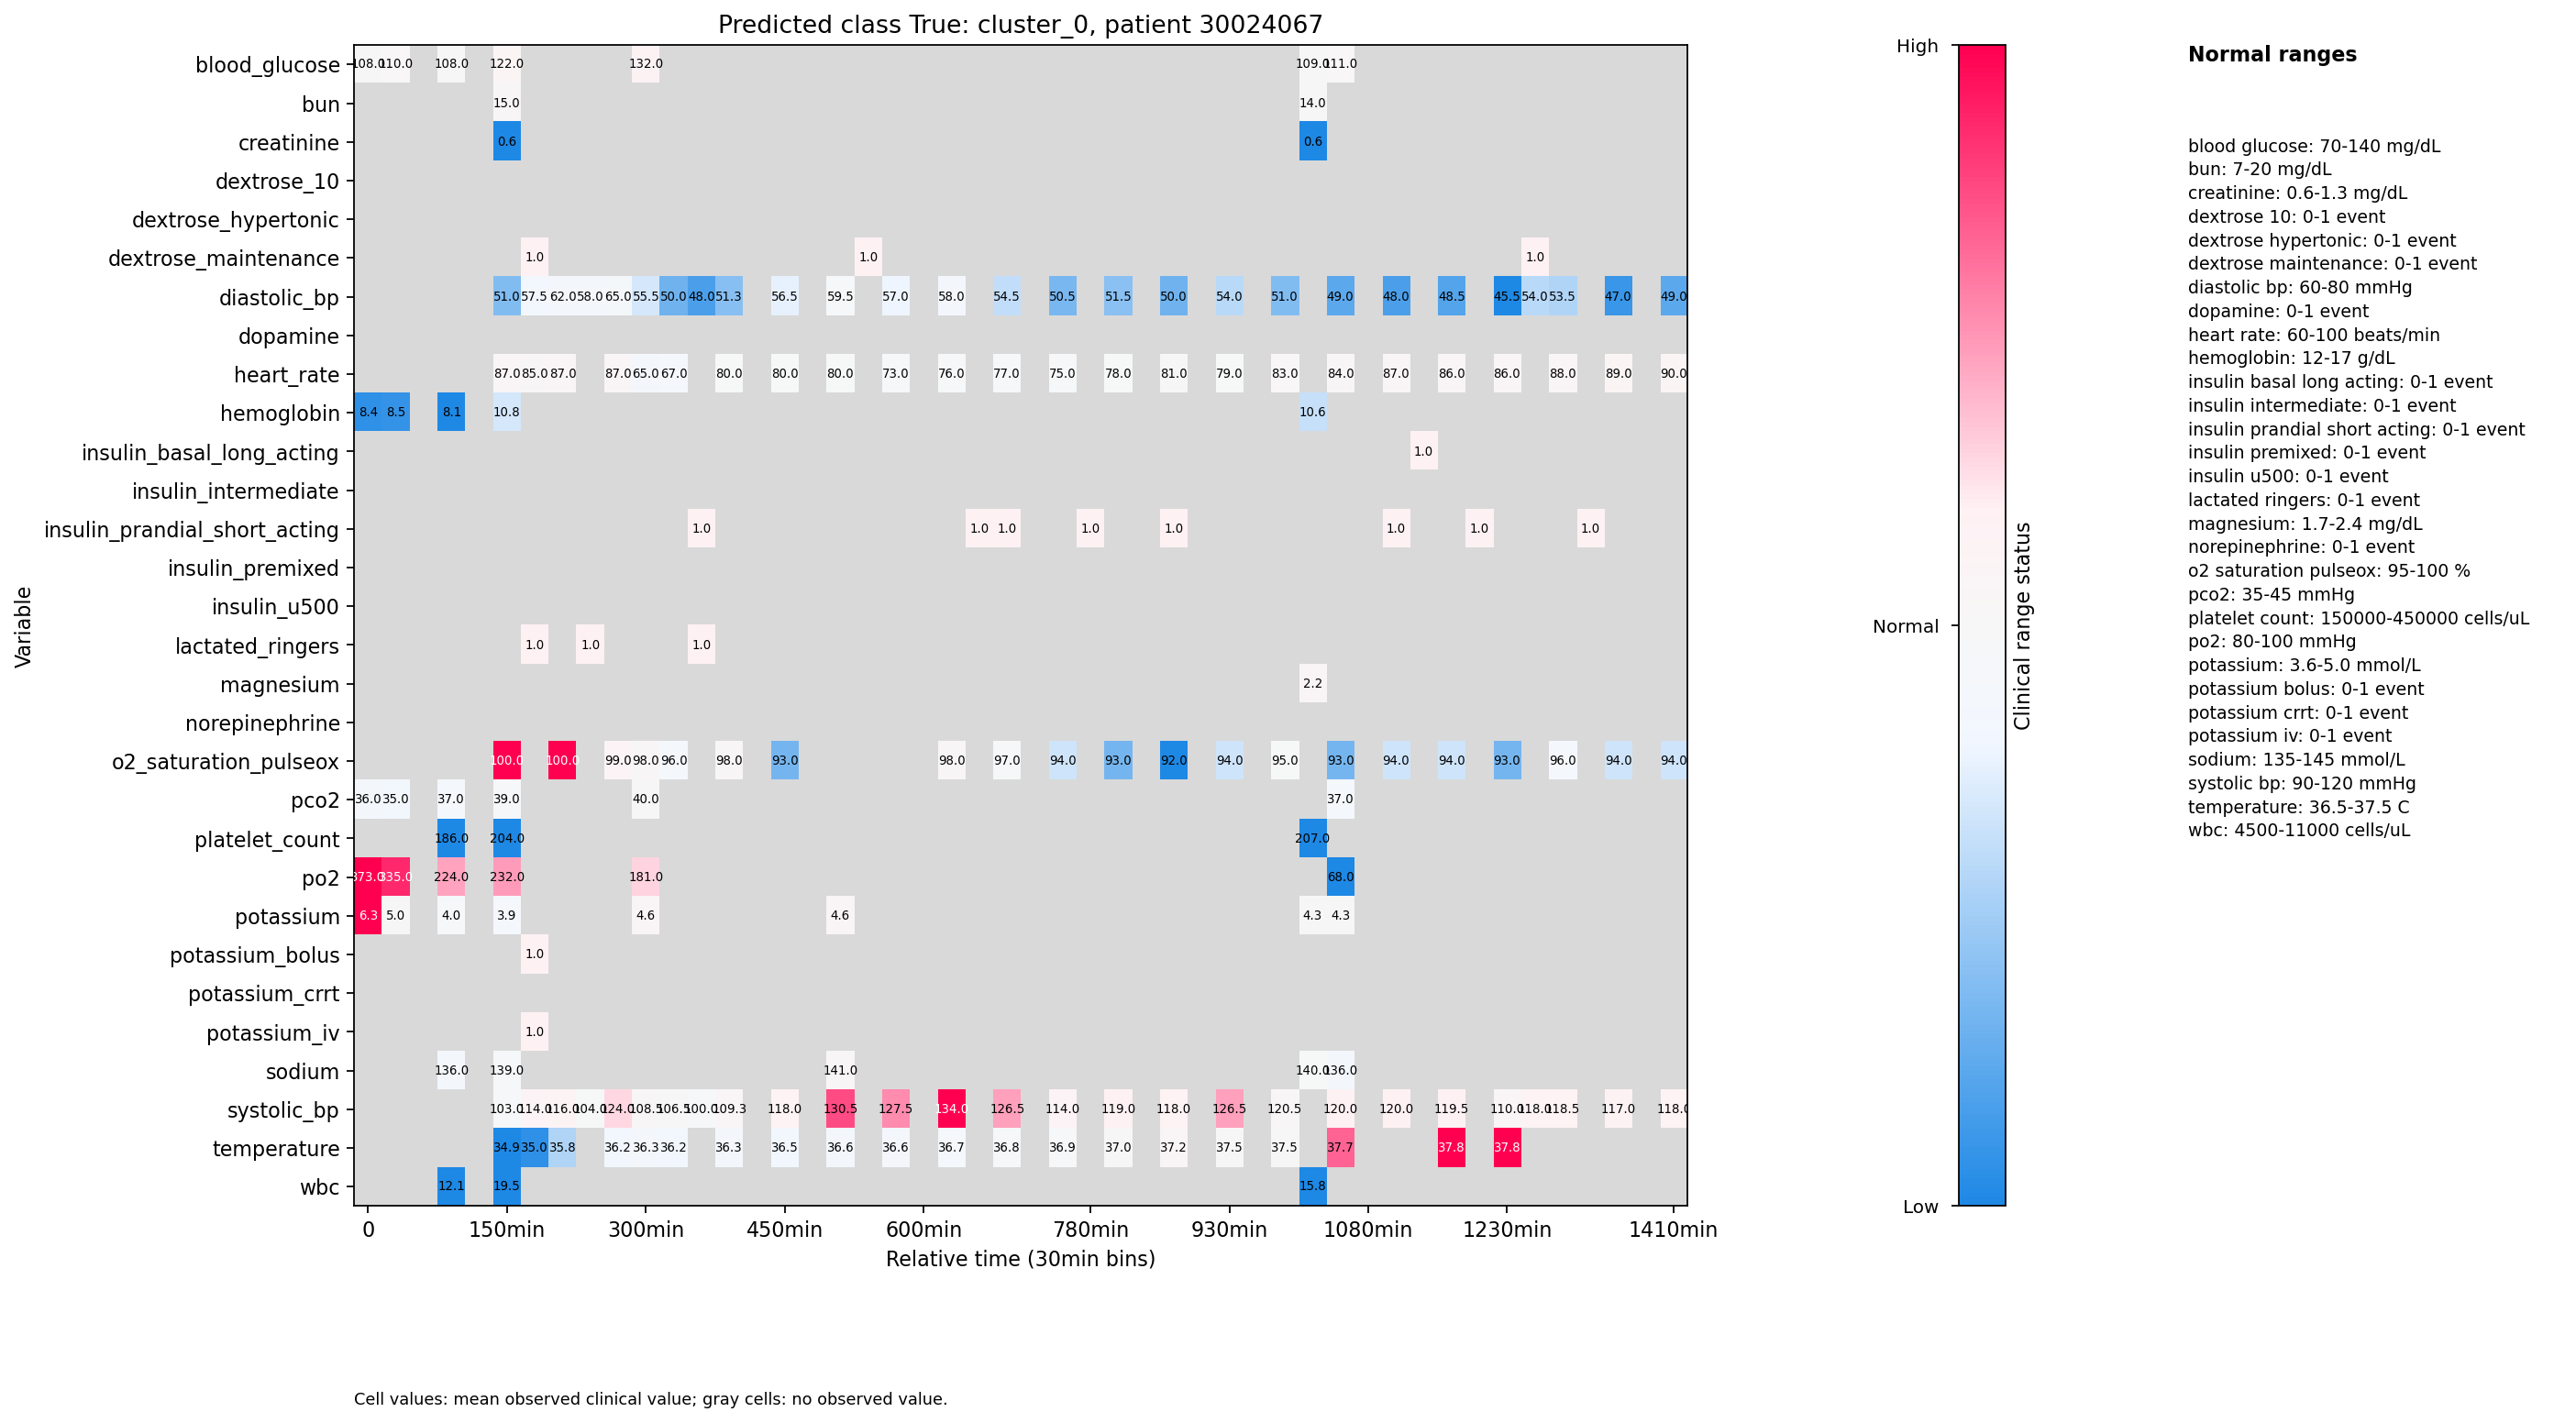

PosixPath('/home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/selected_patient_heatmaps/test/True/cluster_0/patient_30024067_values.png')

In [8]:
plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="values")

/home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/selected_patient_heatmaps/test/True/cluster_0/patient_30024067_importance.png


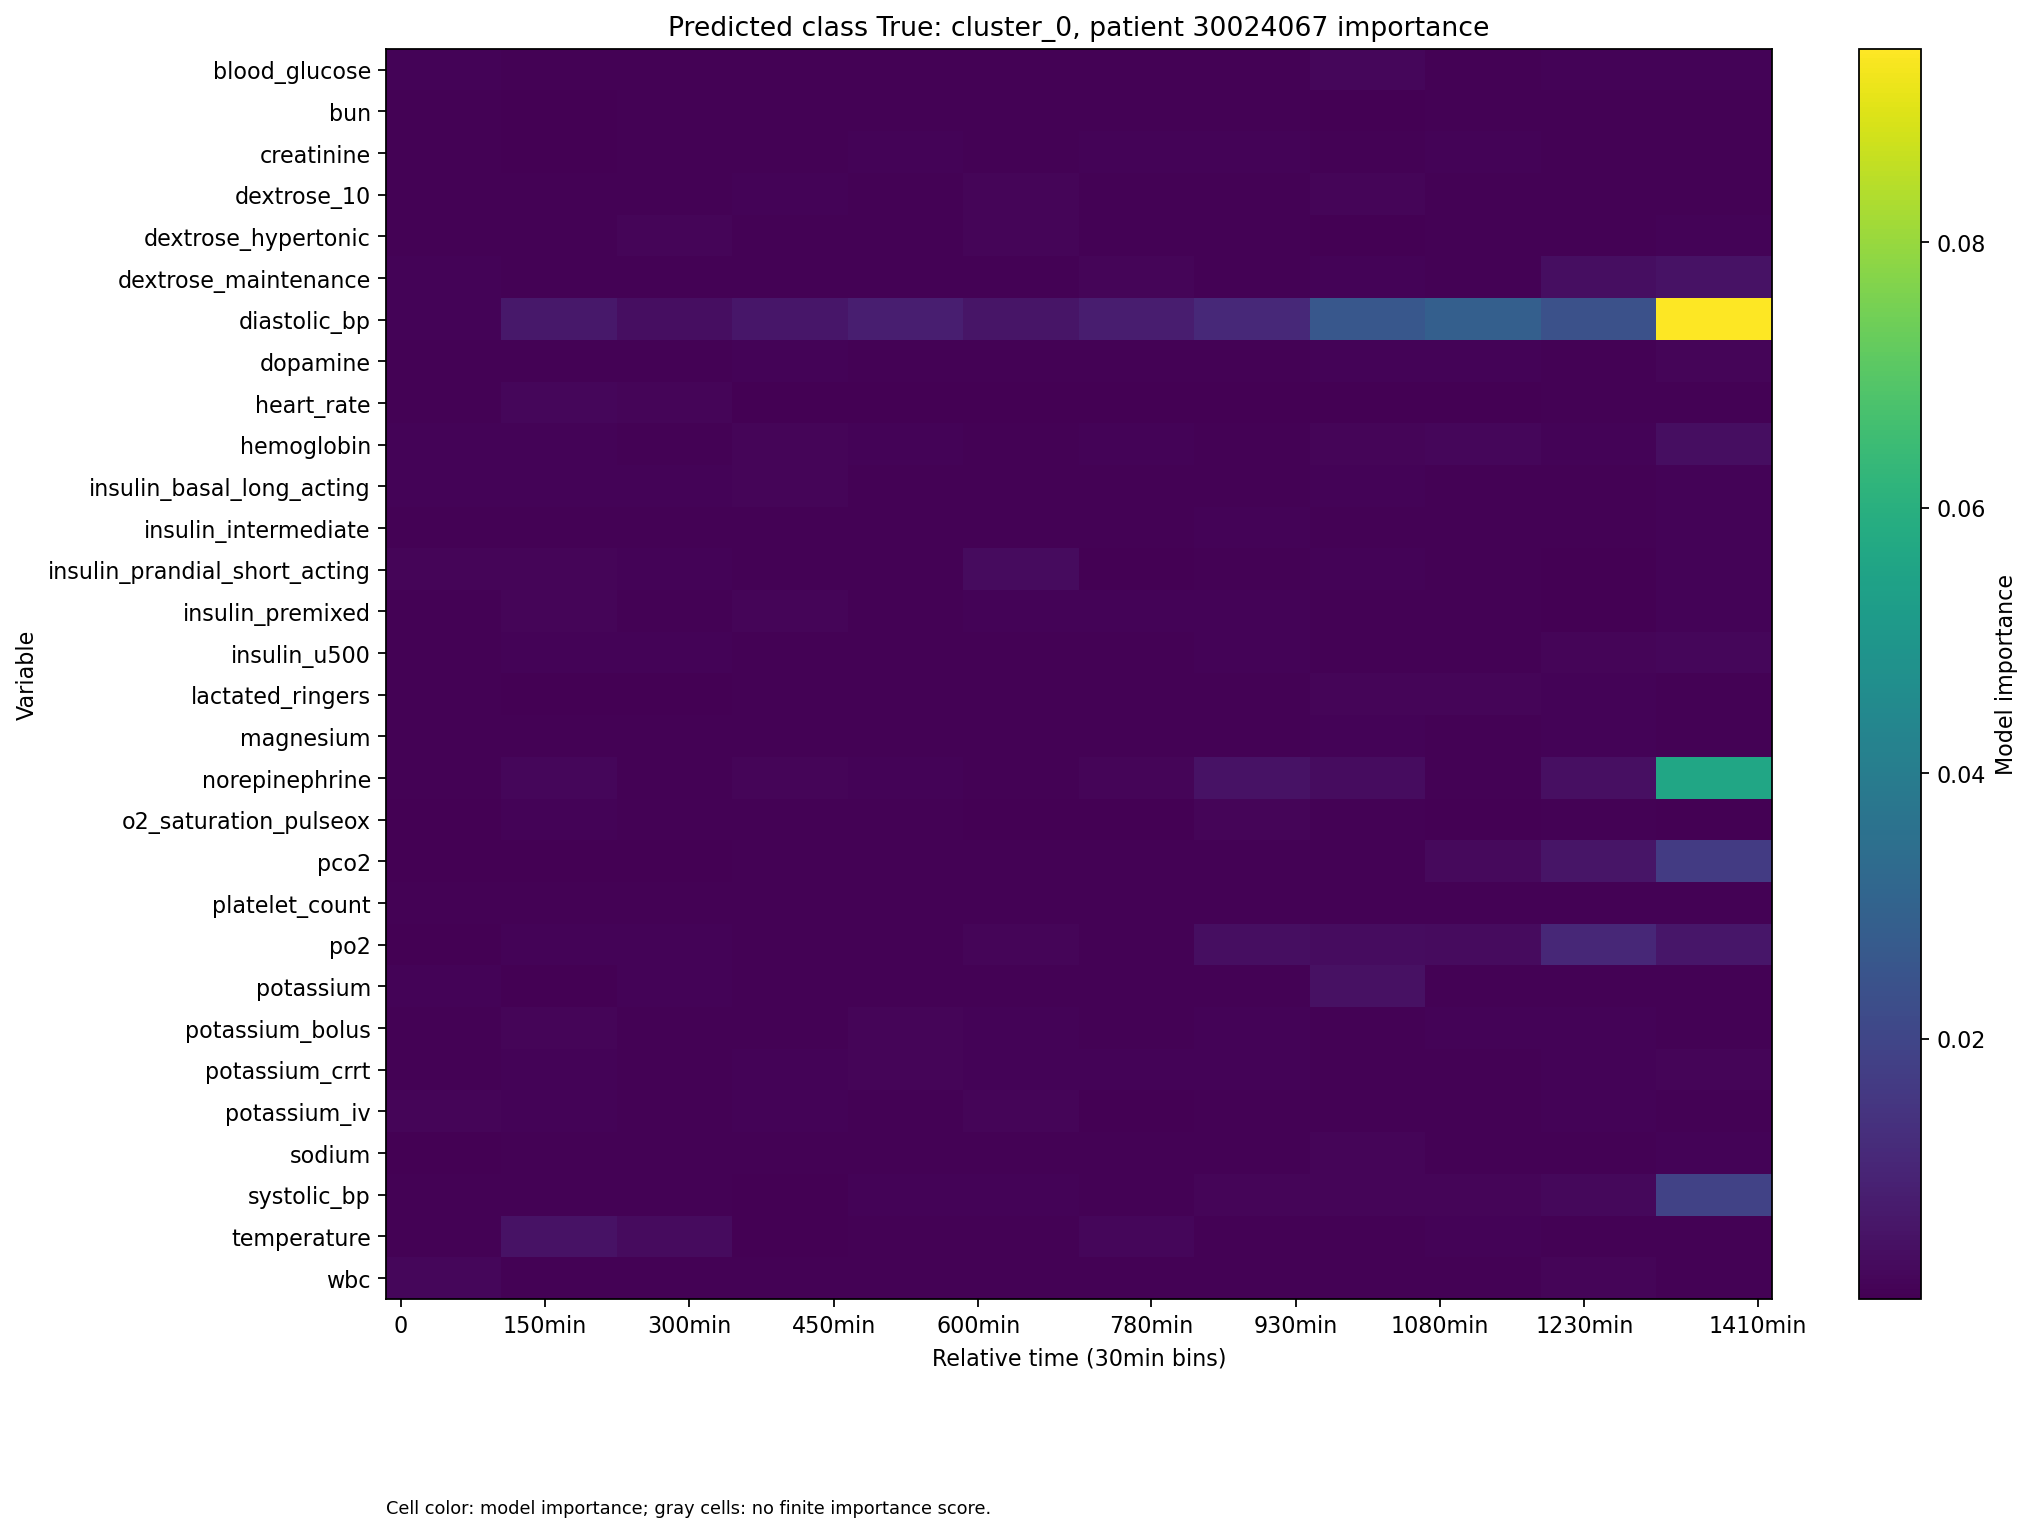

PosixPath('/home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/selected_patient_heatmaps/test/True/cluster_0/patient_30024067_importance.png')

In [9]:
plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="importance")

/home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/selected_patient_heatmaps/test/True/cluster_0/patient_30024067_combined.png


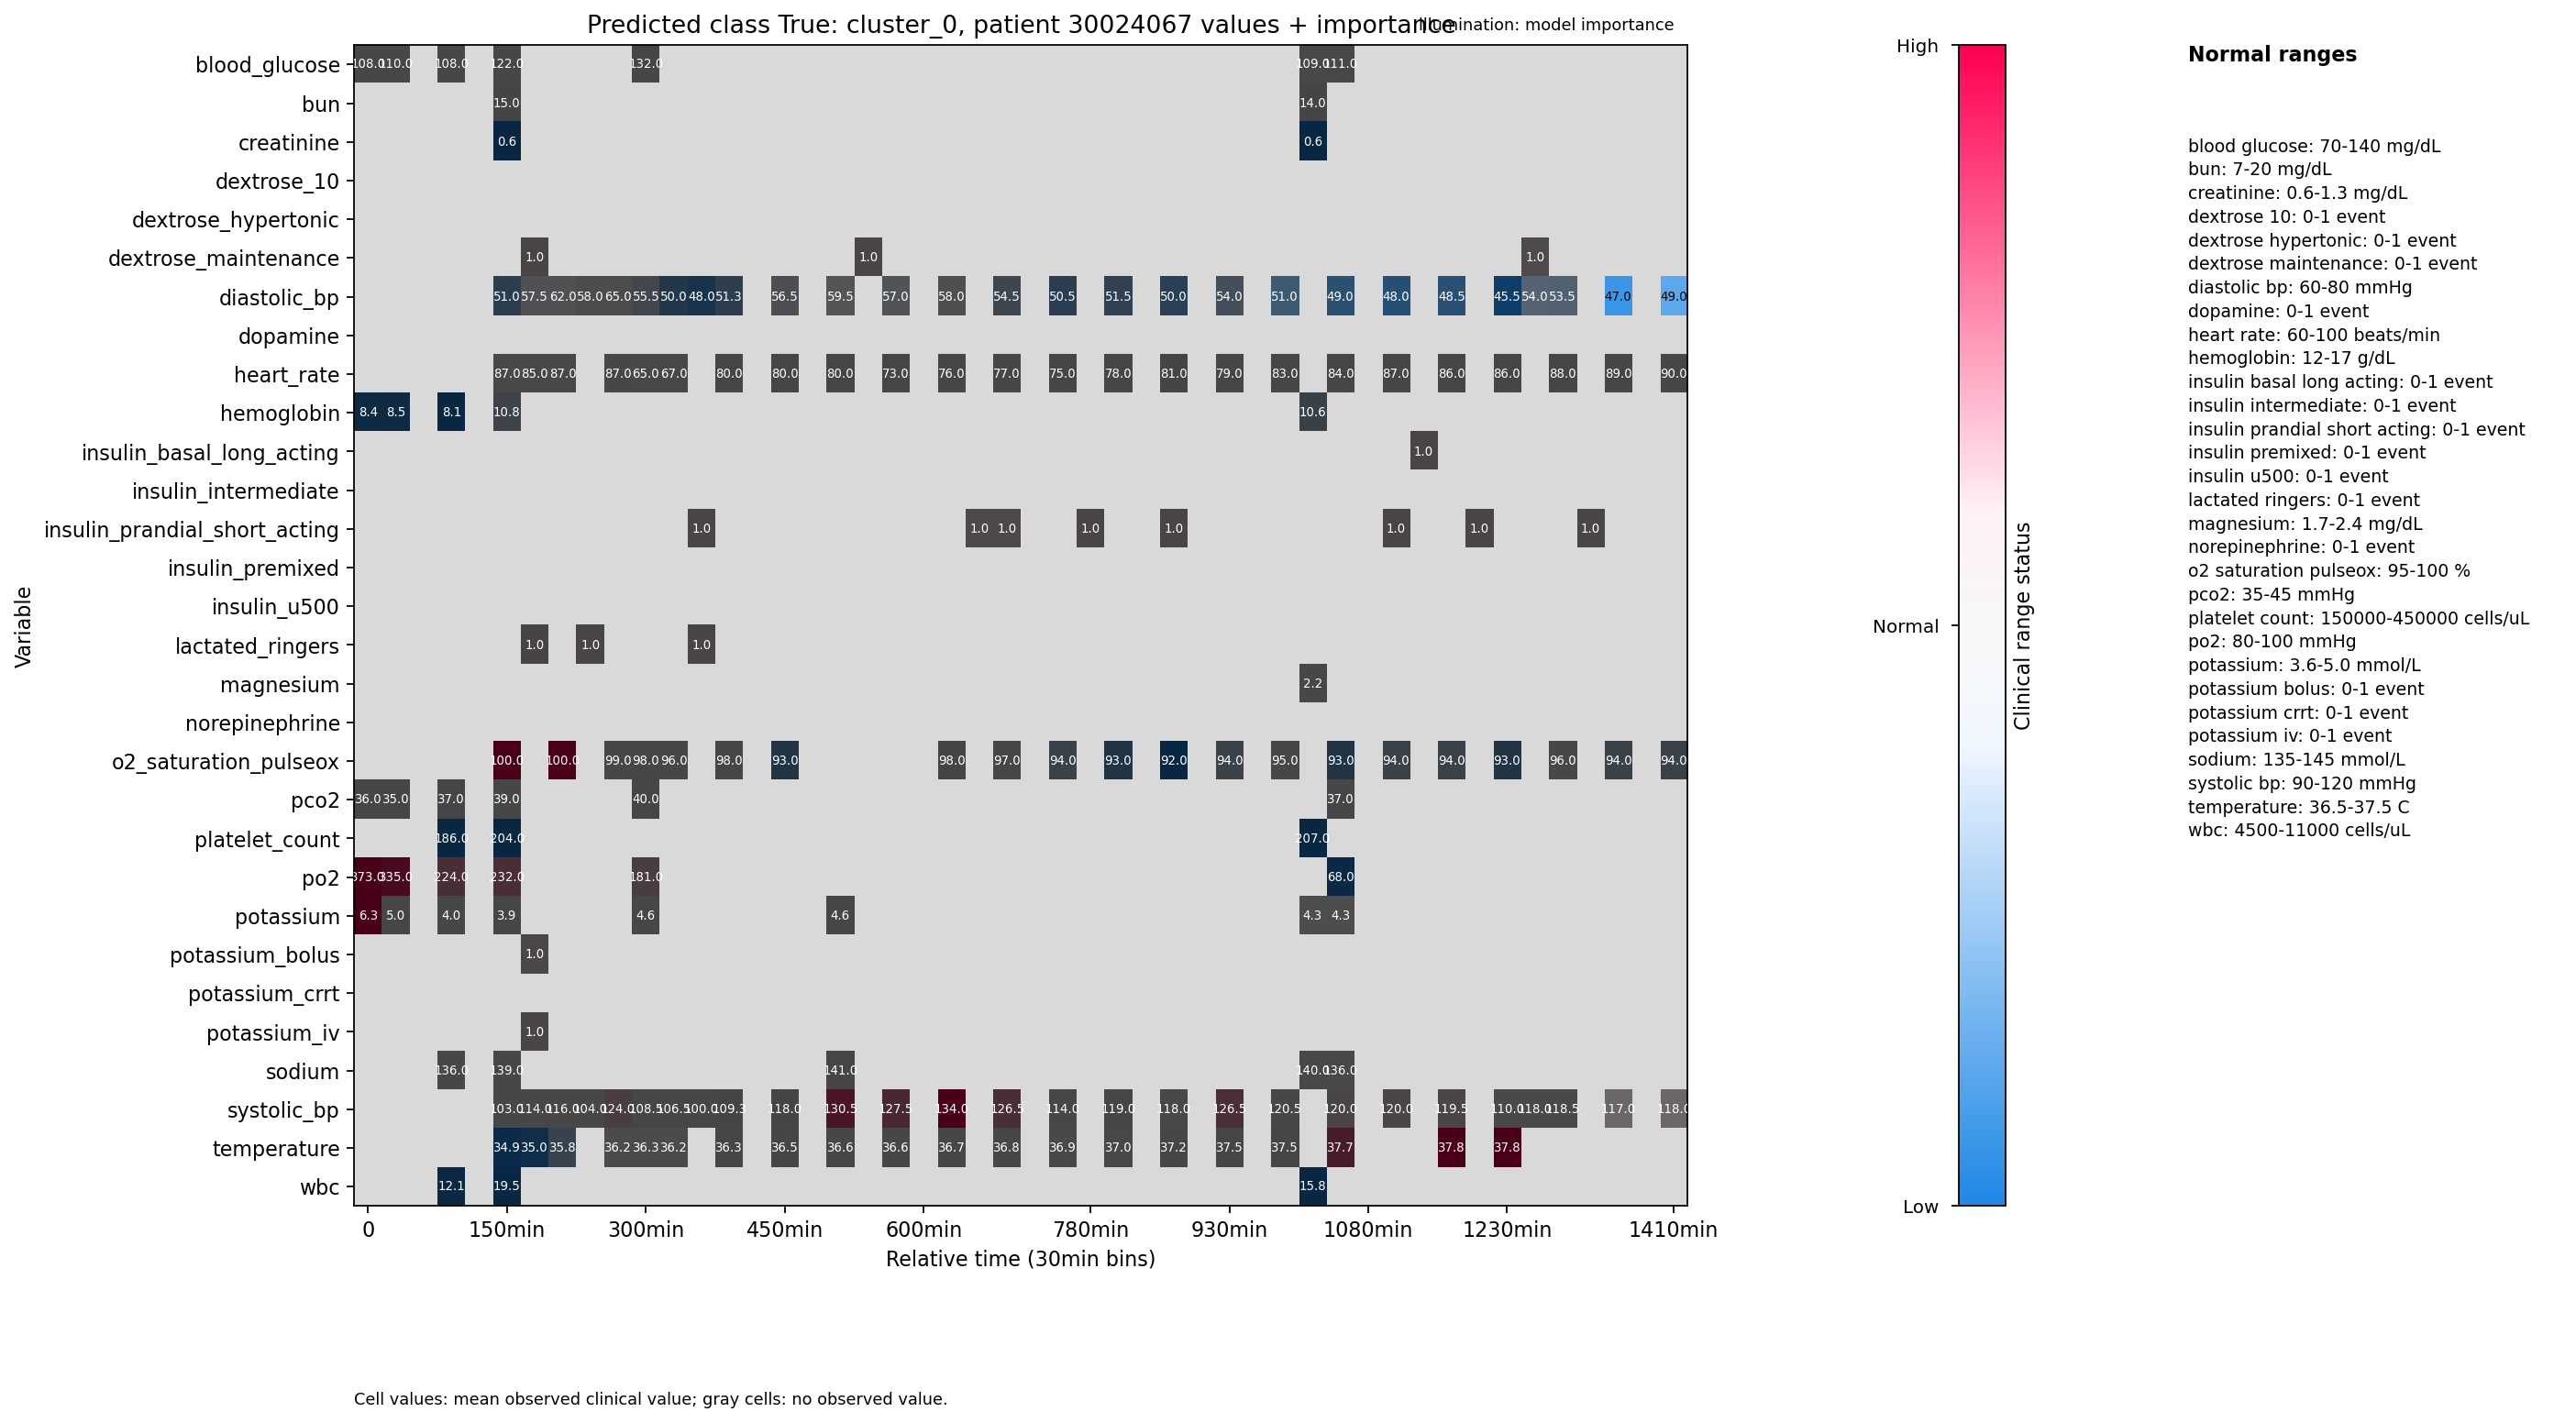

PosixPath('/home/michalwe/Interpretable-ViT-for-Timeseries/runs/mimic_targets/vit_baseline/obs24_target8_gap0/hypotension/selected_patient_heatmaps/test/True/cluster_0/patient_30024067_combined.png')

In [ ]:
plot_patient_from_cluster("True", 0, patient_id="30024067", plot_mode="combined", importance_encoding="spotlight")

## Artifact Check

In [ ]:
important_artifacts = [
    CLUSTERS_DIR / "autoencoder_embeddings.csv",
    CLUSTERS_DIR / "cluster_assignments.csv",
    CLUSTERS_DIR / "cluster_centroids.csv",
    CLUSTERS_DIR / "cluster_metadata.json",
    OUTPUT_DIR,
    SELECTED_OUTPUT_DIR,
    SELECTED_PATIENT_OUTPUT_DIR,
]
display(pd.DataFrame({"exists": [path.exists() for path in important_artifacts], "path": [str(path) for path in important_artifacts]}))